In [1]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

class DRIVEDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        
        # List all images and masks, sorted to ensure they match perfectly
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        # Load image (RGB) and mask (Grayscale)
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)
            
            # Ensure mask is strictly 0 or 1 (binary)
            mask = torch.where(mask > 0.5, 1.0, 0.0)

        return image, mask

In [2]:
# Kaggle's default path for the DRIVE dataset
# Double-check this path in your Kaggle 'input' folder sidebar!
BASE_PATH = "/kaggle/input/datasets/andrewmvd/drive-digital-retinal-images-for-vessel-extraction/DRIVE"

# Define transformations: Resize to 256x256 and convert to PyTorch Tensors
data_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# Create the Training Dataset and DataLoader
train_image_dir = os.path.join(BASE_PATH, "training/images")
train_mask_dir = os.path.join(BASE_PATH, "training/1st_manual")

train_dataset = DRIVEDataset(image_dir=train_image_dir, 
                             mask_dir=train_mask_dir, 
                             transform=data_transform)

# DataLoader handles batching (feeding 4 images at a time to the GPU)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

print(f"Total training images loaded: {len(train_dataset)}")

Total training images loaded: 20


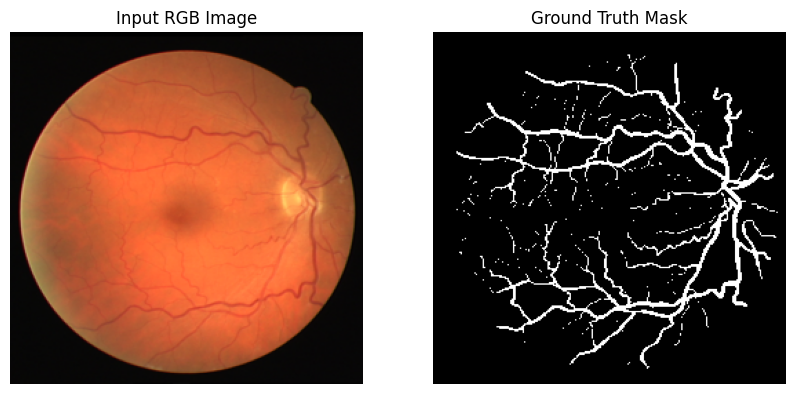

In [3]:
# Grab one batch of data
images, masks = next(iter(train_loader))

# Plot the first image and mask in the batch
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Convert PyTorch tensor back to Numpy for matplotlib
# PyTorch is (Channels, Height, Width), Matplotlib needs (Height, Width, Channels)
img_np = images[0].permute(1, 2, 0).numpy()
mask_np = masks[0].squeeze().numpy() 

ax[0].imshow(img_np)
ax[0].set_title("Input RGB Image")
ax[0].axis('off')

ax[1].imshow(mask_np, cmap='gray')
ax[1].set_title("Ground Truth Mask")
ax[1].axis('off')

plt.show()

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. Channel Attention: Teaches the AI to focus on the most important color/feature channels
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=8):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc1   = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2   = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)

# 2. Spatial Attention: Teaches the AI exactly WHERE the tubular structures are
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = 3 if kernel_size == 7 else 1
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv1(x)
        return self.sigmoid(x)

# 3. The Full CBAM Module combining both
class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=8, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x) # Apply channel weights
        x = x * self.sa(x) # Apply spatial weights
        return x

In [5]:
class DoubleConv(nn.Module):
    """Standard Convolutional block for U-Net"""
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class VeinHunterUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(VeinHunterUNet, self).__init__()
        
        # Encoder (Downsampling)
        self.down1 = DoubleConv(in_channels, 32)
        self.down2 = DoubleConv(32, 64)
        self.down3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)
        
        # Decoder (Upsampling)
        self.upConv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up3 = DoubleConv(256, 128) # 128 from up, 128 from skip
        self.cbam3 = CBAM(128) # NOVELTY INJECTED HERE
        
        self.upConv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up2 = DoubleConv(128, 64)
        self.cbam2 = CBAM(64)  # NOVELTY INJECTED HERE
        
        self.upConv1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.up1 = DoubleConv(64, 32)
        self.cbam1 = CBAM(32)  # NOVELTY INJECTED HERE
        
        # Final Output
        self.out_conv = nn.Conv2d(32, out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder path
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        
        # Bottleneck
        b = self.bottleneck(self.pool(x3))
        
        # Decoder path with Skip Connections and Attention
        x = self.upConv3(b)
        x = torch.cat([x, x3], dim=1) # Skip connection
        x = self.up3(x)
        x = self.cbam3(x)             # Apply Attention
        
        x = self.upConv2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up2(x)
        x = self.cbam2(x)             # Apply Attention
        
        x = self.upConv1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up1(x)
        x = self.cbam1(x)             # Apply Attention
        
        # Output logic
        logits = self.out_conv(x)
        return self.sigmoid(logits)

print("Architecture successfully defined!")

Architecture successfully defined!


In [6]:
# Create a dummy tensor representing 1 batch of 3-channel RGB image sized 256x256
dummy_input = torch.randn(1, 3, 256, 256)

# Initialize your model
model = VeinHunterUNet()

# Pass the dummy image through the network
dummy_output = model(dummy_input)

print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {dummy_output.shape}") 
# Expected Output shape: torch.Size([1, 1, 256, 256])

Input shape: torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 1, 256, 256])


In [7]:
import torch.nn.functional as F

class DiceBCEWithLogitsLoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCEWithLogitsLoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        # Flatten label and prediction tensors
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        # Binary Cross Entropy
        BCE = F.binary_cross_entropy(inputs, targets, reduction='mean')
        
        # Dice Loss calculation
        intersection = (inputs * targets).sum()                            
        dice_loss = 1 - (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)  
        
        # Combine both (you can weigh them differently, but 1:1 is a good start)
        Dice_BCE = BCE + dice_loss
        
        return Dice_BCE

# Initialize our custom loss
criterion = DiceBCEWithLogitsLoss()
print("Custom Loss Function initialized!")

Custom Loss Function initialized!


In [8]:
from torch.utils.data import random_split
import torch

# 1. Point ONLY to the training folders (because they have the correct 1st_manual masks)
image_dir = os.path.join(BASE_PATH, "training/images")
mask_dir = os.path.join(BASE_PATH, "training/1st_manual")

# 2. Load all 20 perfect images into one main dataset
full_dataset = DRIVEDataset(image_dir=image_dir, 
                            mask_dir=mask_dir, 
                            transform=data_transform)

# 3. Mathematically split the dataset (16 for training, 4 for validation)
train_size = 16
val_size = len(full_dataset) - train_size

# Set a manual seed so the random split is identical every time you run the cell
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

# 4. Create the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

print(f"Total dataset size: {len(full_dataset)}")
print(f" -> Allocated for Training: {len(train_dataset)}")
print(f" -> Allocated for Validation: {len(val_dataset)}")

Total dataset size: 20
 -> Allocated for Training: 16
 -> Allocated for Validation: 4


In [ ]:
import torch.optim as optim

# 1. Setup Device and Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VeinHunterUNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 2. Early Stopping Parameters
num_epochs = 300       # We set a high maximum, trusting Early Stopping to halt it
patience = 15          # How many epochs to wait for an improvement before stopping
patience_counter = 0
best_val_loss = float('inf')

print(f"Starting training on {device} with Early Stopping...")

for epoch in range(num_epochs):
    # ===============================
    #       TRAINING PHASE
    # ===============================
    model.train() 
    epoch_train_loss = 0
    
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward, backward, and optimize
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
        
    avg_train_loss = epoch_train_loss / len(train_loader)
    
    # ===============================
    #       VALIDATION PHASE
    # ===============================
    model.eval() # Freezes Dropout and BatchNorm layers
    epoch_val_loss = 0
    
    with torch.no_grad(): # Disables gradient calculation to save memory/speed
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            epoch_val_loss += loss.item()
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    
    # Print the stats for this epoch
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # ===============================
    #     EARLY STOPPING LOGIC
    # ===============================
    if avg_val_loss < best_val_loss:
        # The model improved! Save it and reset patience.
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'vein_hunter_best_weights.pth')
        print("   -> Validation loss decreased! Saving best model.")
    else:
        # The model did not improve.
        patience_counter += 1
        print(f"   -> No improvement. Patience: {patience_counter}/{patience}")
        
    # Check if we have run out of patience
    if patience_counter >= patience:
        print(f"\n[!] Early stopping triggered at epoch {epoch+1}!")
        print("Training halted to prevent overfitting.")
        break

print("\nTraining Complete! The absolute best weights are saved as 'vein_hunter_best_weights.pth'.")

In [ ]:
import matplotlib.pyplot as plt
import torch

# 1. Initialize a fresh model and load your best weights
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
inference_model = VeinHunterUNet().to(device)
inference_model.load_state_dict(torch.load('vein_hunter_best_weights.pth'))
inference_model.eval() # Set to evaluation mode (critical!)

# 2. Grab a single batch of unseen test data
images, true_masks = next(iter(val_loader))

# Take just the first image in the batch
single_image = images[0].unsqueeze(0).to(device) 
true_mask = true_masks[0].squeeze().numpy()

# 3. Make the Prediction
with torch.no_grad():
    prediction = inference_model(single_image)
    
# Convert prediction to numpy and remove extra dimensions
# The model outputs a probability (0.0 to 1.0). We threshold at 0.5 to make it strict black/white.
pred_mask = prediction.squeeze().cpu().numpy()
binary_pred_mask = (pred_mask > 0.5).astype(float)

# 4. Plot the Results
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Original RGB Image
# PyTorch is (C, H, W) -> Matplotlib expects (H, W, C)
img_display = images[0].permute(1, 2, 0).numpy()
ax[0].imshow(img_display)
ax[0].set_title("1. Original RGB Input")
ax[0].axis('off')

# Ground Truth
ax[1].imshow(true_mask, cmap='gray')
ax[1].set_title("2. Ground Truth (Human Labeled)")
ax[1].axis('off')

# AI Prediction
ax[2].imshow(binary_pred_mask, cmap='gray')
ax[2].set_title("3. Vein Hunter AI Prediction")
ax[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

# ==========================================
# 1. The Universal Dataset Class
# ==========================================
# Instead of pointing this to folders, we feed it exact lists of file paths.
# This makes it immune to weird folder structures.
class MegaRetinaDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        # Load RGB image and Grayscale mask
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)
            # Binary thresholding for the mask
            mask = torch.where(mask > 0.5, 1.0, 0.0)

        return image, mask

import re

# ==========================================
# 2. Robust Path Gathering Helper Function
# ==========================================
def gather_paths(image_dir, mask_dir):
    """Smartly matches images and masks by extracting their core ID numbers."""
    # Grab all valid files
    img_files = sorted([f for f in os.listdir(image_dir) if not f.startswith('.')])
    mask_files = sorted([f for f in os.listdir(mask_dir) if not f.startswith('.')])

    def extract_id(filename):
        # Finds the first sequence of numbers in the filename (e.g., "21_training.tif" -> "21")
        match = re.search(r'\d+', filename)
        return match.group() if match else filename.split('.')[0]

    # Create dictionaries linking the extracted ID to the actual filename
    img_dict = {extract_id(f): f for f in img_files}
    mask_dict = {extract_id(f): f for f in mask_files}

    # Find ONLY the IDs that exist in BOTH folders (dropping the rogue 601st image)
    common_ids = sorted(list(set(img_dict.keys()) & set(mask_dict.keys())))

    img_paths = []
    mask_paths = []
    
    for file_id in common_ids:
        img_paths.append(os.path.join(image_dir, img_dict[file_id]))
        mask_paths.append(os.path.join(mask_dir, mask_dict[file_id]))

    # Print out how many safe pairs we salvaged
    folder_name = os.path.basename(os.path.normpath(image_dir))
    print(f" -> {folder_name}: Safely matched {len(img_paths)} valid pairs.")
    
    return img_paths, mask_paths

# ==========================================
# 3. Define Base Directories (From your screenshot)
# ==========================================
# Double check these by clicking "Copy Path" in Kaggle if you hit a FileNotFoundError!
DRIVE_BASE = "/kaggle/input/datasets/andrewmvd/drive-digital-retinal-images-for-vessel-extraction/DRIVE"
FUNDUS_BASE = "//kaggle/input/datasets/nikitamanaenkov/fundus-image-dataset-for-vessel-segmentation"

# 1. Gather DRIVE Training Data
d_img_dir = os.path.join(DRIVE_BASE, "training/images")
d_msk_dir = os.path.join(DRIVE_BASE, "training/1st_manual")
drive_imgs, drive_masks = gather_paths(d_img_dir, d_msk_dir)

# 2. Gather Fundus Training Data
ft_img_dir = os.path.join(FUNDUS_BASE, "train/Original")
ft_msk_dir = os.path.join(FUNDUS_BASE, "train/Ground truth")
fundus_train_imgs, fundus_train_masks = gather_paths(ft_img_dir, ft_msk_dir)

# 3. Gather Fundus Test Data
ftest_img_dir = os.path.join(FUNDUS_BASE, "test/Original")
ftest_msk_dir = os.path.join(FUNDUS_BASE, "test/Ground truth")
fundus_test_imgs, fundus_test_masks = gather_paths(ftest_img_dir, ftest_msk_dir)

# ==========================================
# 4. Combine and Split!
# ==========================================
# Mash all the lists together into one giant dataset
ALL_IMAGES = drive_imgs + fundus_train_imgs + fundus_test_imgs
ALL_MASKS = drive_masks + fundus_train_masks + fundus_test_masks

print(f"Successfully pooled a total of {len(ALL_IMAGES)} retinal images!")

# Standard Resize Transform
data_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# Initialize our Mega Dataset
mega_dataset = MegaRetinaDataset(ALL_IMAGES, ALL_MASKS, transform=data_transform)

# Mathematically split 80/20 for Training vs Early Stopping Validation
train_size = int(0.8 * len(mega_dataset))
val_size = len(mega_dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(mega_dataset, [train_size, val_size], generator=generator)

# Create the final Loaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

print(f" -> Allocated {len(train_dataset)} images for Mega-Training")
print(f" -> Allocated {len(val_dataset)} images for Validation (Early Stopping checks)")

In [9]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Initialize a FRESH model (Training from scratch on the 820 images)
mega_model = VeinHunterUNet().to(device)

# 2. Define Optimizer (Standard learning rate, no frozen layers)
optimizer = optim.Adam(mega_model.parameters(), lr=1e-4)

# 3. Early Stopping Parameters
num_epochs = 150
patience = 15 
best_val_loss = float('inf')
patience_counter = 0

print("Starting MEGA Pre-Training on 820 Retinal Images...")

for epoch in range(num_epochs):
    # TRAINING
    mega_model.train() 
    epoch_train_loss = 0
    # Make sure 'train_loader' here is your Mega-DataLoader from the previous step!
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = mega_model(images)
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
        
    avg_train_loss = epoch_train_loss / len(train_loader)
    
    # VALIDATION
    mega_model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = mega_model(images)
            loss = criterion(outputs, masks)
            epoch_val_loss += loss.item()
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # EARLY STOPPING LOGIC
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Saving with a NEW name so we don't overwrite your old work
        torch.save(mega_model.state_dict(), 'vein_hunter_MEGA_weights.pth')
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"\n[!] Early stopping triggered. Mega-Training complete!")
        break

print("\nSaved absolute best foundation model as 'vein_hunter_MEGA_weights.pth'")

Starting MEGA Pre-Training on 820 Retinal Images...
Epoch [1/150] | Train Loss: 1.6493 | Val Loss: 1.6296
Epoch [2/150] | Train Loss: 1.6313 | Val Loss: 1.6319
Epoch [3/150] | Train Loss: 1.6214 | Val Loss: 1.6344
Epoch [4/150] | Train Loss: 1.6102 | Val Loss: 1.6370


KeyboardInterrupt: 

In [ ]:
import os
import torch
import cv2 
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

class CustomVeinDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, color_jitter=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.color_jitter = color_jitter
        self.images = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        base_name = os.path.splitext(img_name)[0] 
        mask_name = f"{base_name}_mask.png"
        
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        # --- THE FIX: Load with OpenCV to match your Annotator ---
        # 1. Load RGB Image exactly as your annotator did
        img_cv = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
        image = Image.fromarray(img_rgb)

        # 2. Load Mask as Grayscale
        mask_cv = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = Image.fromarray(mask_cv)
        # -------------------------------------------------------

        # Resize them strictly together for the neural network
        image = image.resize((256, 256))
        mask = mask.resize((256, 256))

        if self.color_jitter:
            image = self.color_jitter(image)

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)
            mask = torch.where(mask > 0.5, 1.0, 0.0)

        return image, mask

# Paths based on your Kaggle dataset structure
CUSTOM_DATA_PATH = "//kaggle/input/datasets/radhikaa1012/vein-hunter-data/vein-hunter-data"
img_dir = os.path.join(CUSTOM_DATA_PATH, "CV_project_images")
msk_dir = os.path.join(CUSTOM_DATA_PATH, "masks")

# Removed the resize from here since it is handled safely inside the class
data_transform = transforms.Compose([
    transforms.ToTensor() 
])

jitter = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)

full_custom_dataset = CustomVeinDataset(image_dir=img_dir, mask_dir=msk_dir, 
                                        transform=data_transform, color_jitter=jitter)

train_size = int(0.8 * len(full_custom_dataset))
val_size = len(full_custom_dataset) - train_size
generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(full_custom_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

print(f"Loaded {len(full_custom_dataset)} Human Arm images.")

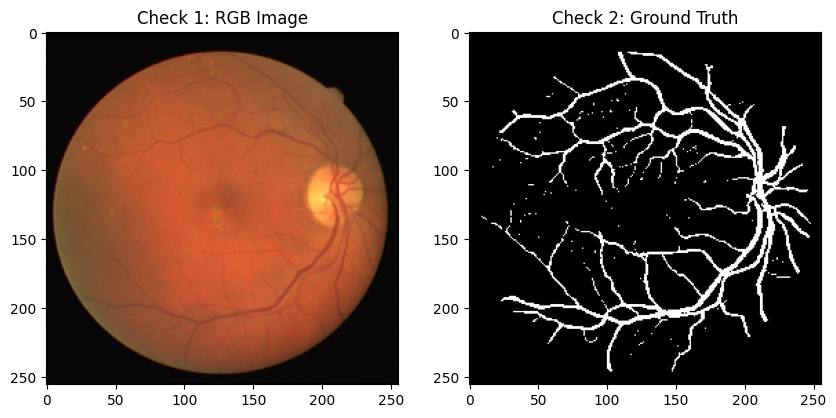

In [10]:
# Grab one batch from your updated loader
test_imgs, test_masks = next(iter(train_loader))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(test_imgs[3].permute(1, 2, 0).numpy())
ax[0].set_title("Check 1: RGB Image")
ax[1].imshow(test_masks[3].squeeze().numpy(), cmap='gray')
ax[1].set_title("Check 2: Ground Truth")
plt.show()

In [11]:
import torch.optim as optim
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Initialize network and load MEGA weights
model = VeinHunterUNet().to(device)
WEIGHTS_PATH = "/kaggle/working/vein_hunter_MEGA_weights.pth" 
model.load_state_dict(torch.load(WEIGHTS_PATH))
print("Mega-Retinal foundation successfully loaded!")

# 2. Freeze the Encoder (Locking in the 820-image knowledge)
for param in model.down1.parameters(): param.requires_grad = False
for param in model.down2.parameters(): param.requires_grad = False
for param in model.down3.parameters(): param.requires_grad = False

# 3. Tiny learning rate so we don't break the foundation
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)

# 4. Fast Early Stopping
num_epochs = 100
patience = 10 
best_val_loss = float('inf')
patience_counter = 0

print("Starting Transfer Learning on Human Arms...")

for epoch in range(num_epochs):
    model.train() 
    epoch_train_loss = 0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
        
    avg_train_loss = epoch_train_loss / len(train_loader)
    
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            epoch_val_loss += loss.item()
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'vein_hunter_FINAL_SKIN_weights.pth')
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"\n[!] Early stopping triggered. Transfer Learning complete!")
        break

print("\nSaved absolute final model as 'vein_hunter_FINAL_SKIN_weights.pth'")

Mega-Retinal foundation successfully loaded!
Starting Transfer Learning on Human Arms...
Epoch [1/100] | Train Loss: 1.6340 | Val Loss: 1.6319
Epoch [2/100] | Train Loss: 1.6333 | Val Loss: 1.6338
Epoch [3/100] | Train Loss: 1.6307 | Val Loss: 1.6355
Epoch [4/100] | Train Loss: 1.6308 | Val Loss: 1.6373
Epoch [5/100] | Train Loss: 1.6294 | Val Loss: 1.6382
Epoch [6/100] | Train Loss: 1.6282 | Val Loss: 1.6381
Epoch [7/100] | Train Loss: 1.6276 | Val Loss: 1.6378
Epoch [8/100] | Train Loss: 1.6266 | Val Loss: 1.6378
Epoch [9/100] | Train Loss: 1.6252 | Val Loss: 1.6390
Epoch [10/100] | Train Loss: 1.6241 | Val Loss: 1.6405
Epoch [11/100] | Train Loss: 1.6231 | Val Loss: 1.6404

[!] Early stopping triggered. Transfer Learning complete!

Saved absolute final model as 'vein_hunter_FINAL_SKIN_weights.pth'


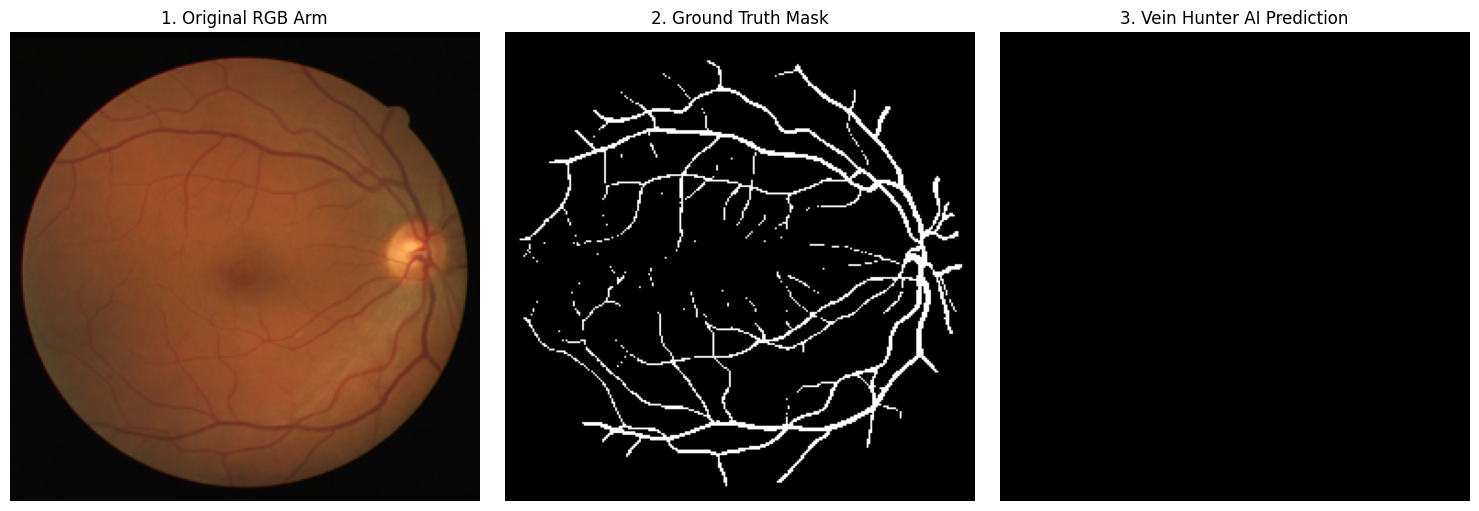

In [12]:
import matplotlib.pyplot as plt

# 1. Load the finalized Skin Weights
inference_model = VeinHunterUNet().to(device)
inference_model.load_state_dict(torch.load('vein_hunter_FINAL_SKIN_weights.pth'))
inference_model.eval() 

# 2. Grab a batch of unseen arm photos
images, true_masks = next(iter(val_loader))
single_image = images[0].unsqueeze(0).to(device) 
true_mask = true_masks[0].squeeze().numpy()

# 3. Make the Prediction
with torch.no_grad():
    prediction = inference_model(single_image)
    
pred_mask = prediction.squeeze().cpu().numpy()
binary_pred_mask = (pred_mask > 0.5).astype(float)

# 4. Plot the Results side-by-side
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Original RGB Image
img_display = images[0].permute(1, 2, 0).numpy()
ax[0].imshow(img_display)
ax[0].set_title("1. Original RGB Arm")
ax[0].axis('off')

# Ground Truth
ax[1].imshow(true_mask, cmap='gray')
ax[1].set_title("2. Ground Truth Mask")
ax[1].axis('off')

# AI Prediction
ax[2].imshow(binary_pred_mask, cmap='gray')
ax[2].set_title("3. Vein Hunter AI Prediction")
ax[2].axis('off')

plt.tight_layout()
plt.show()

In [13]:
import os
import torch
import cv2 
import random # NEW
import torchvision.transforms.functional as TF # NEW
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

class CustomVeinDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, color_jitter=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform 
        self.color_jitter = color_jitter
        self.images = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        base_name = os.path.splitext(img_name)[0] 
        mask_name = f"{base_name}_mask.png"
        
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        # ==========================================
        # THE FIX: Return to Natural RGB Color!
        # ==========================================
        img_cv = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB) # Normal color!
        image = Image.fromarray(img_rgb)

        # Load Mask
        mask_cv = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = Image.fromarray(mask_cv)

        # Resize Strictly Together
        image = image.resize((256, 256))
        mask = mask.resize((256, 256))

        # Safely Locked Spatial Augmentation (Keep this!)
        if random.random() > 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)
            
        if random.random() > 0.5:
            image = TF.vflip(image)
            mask = TF.vflip(mask)
            
        angle = random.uniform(-45, 45)
        image = TF.rotate(image, angle)
        mask = TF.rotate(mask, angle)

        if self.color_jitter:
            image = self.color_jitter(image)

        # Convert to PyTorch Tensors
        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)
            mask = torch.where(mask > 0.5, 1.0, 0.0)

        return image, mask
        
# Paths based on your Kaggle dataset structure
CUSTOM_DATA_PATH = "/kaggle/input/datasets/pragatirokade/images"
img_dir = os.path.join(CUSTOM_DATA_PATH, "CV_project_images - Copy")
msk_dir = os.path.join(CUSTOM_DATA_PATH, "masks - Copy")

# We ONLY leave ToTensor here, all spatial math is safely handled inside the class
data_transform = transforms.Compose([
    transforms.ToTensor() 
])

jitter = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)

full_custom_dataset = CustomVeinDataset(image_dir=img_dir, mask_dir=msk_dir, 
                                        transform=data_transform, color_jitter=jitter)

train_size = int(0.8 * len(full_custom_dataset))
val_size = len(full_custom_dataset) - train_size
generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(full_custom_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

print(f"Loaded {len(full_custom_dataset)} Human Arm images safely!")

Loaded 116 Human Arm images safely!


In [15]:
import torch.optim as optim
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# FIX: The Loss Function (No Double-Sigmoid!)
# ==========================================
class DiceBCELoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        # Flatten label and prediction tensors
        # REMOVED torch.sigmoid(inputs) here, because your U-Net already does it!
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        # Calculate intersection
        intersection = (inputs * targets).sum()                            
        dice_loss = 1 - (2. * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)  
        
        # Calculate standard Binary Cross Entropy
        BCE = F.binary_cross_entropy(inputs, targets, reduction='mean')
        
        return BCE + dice_loss

# Initialize the custom loss function
criterion = DiceBCELoss()

# ==========================================
# 1. Initialize network and load MEGA weights
# ==========================================
model = VeinHunterUNet().to(device)
WEIGHTS_PATH = "/kaggle/input/datasets/pragatirokade/vein-hunter-mega-weights/vein_hunter_MEGA_weights.pth" 
model.load_state_dict(torch.load(WEIGHTS_PATH))
print("Mega-Retinal foundation successfully loaded!")

# ==========================================
# FIX: Unfreeze the Encoder
# ==========================================
# We MUST let the early layers learn the new "Synthetic RGB" colors!
for param in model.parameters(): 
    param.requires_grad = True

# 3. Use standard learning rate
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 4. Fast Early Stopping
num_epochs = 100
patience = 10 
best_val_loss = float('inf')
patience_counter = 0

print("Starting Transfer Learning on Human Arms with Dice+BCE Loss...")

for epoch in range(num_epochs):
    model.train() 
    epoch_train_loss = 0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
        
    avg_train_loss = epoch_train_loss / len(train_loader)
    
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            epoch_val_loss += loss.item()
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'vein_hunter_FINAL_SKIN_weights.pth')
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"\n[!] Early stopping triggered. Transfer Learning complete!")
        break

print("\nSaved absolute final model as 'vein_hunter_FINAL_SKIN_weights.pth'")

Mega-Retinal foundation successfully loaded!
Starting Transfer Learning on Human Arms with Dice+BCE Loss...
Epoch [1/100] | Train Loss: 1.1393 | Val Loss: 1.0236
Epoch [2/100] | Train Loss: 0.9955 | Val Loss: 1.0151
Epoch [3/100] | Train Loss: 0.9449 | Val Loss: 0.9422
Epoch [4/100] | Train Loss: 0.8818 | Val Loss: 0.9521
Epoch [5/100] | Train Loss: 0.8369 | Val Loss: 0.8800
Epoch [6/100] | Train Loss: 0.7816 | Val Loss: 0.7684
Epoch [7/100] | Train Loss: 0.7591 | Val Loss: 0.7870
Epoch [8/100] | Train Loss: 0.7335 | Val Loss: 0.7627
Epoch [9/100] | Train Loss: 0.7354 | Val Loss: 0.8660
Epoch [10/100] | Train Loss: 0.7278 | Val Loss: 0.7282
Epoch [11/100] | Train Loss: 0.7146 | Val Loss: 0.6974
Epoch [12/100] | Train Loss: 0.7032 | Val Loss: 0.7232
Epoch [13/100] | Train Loss: 0.6985 | Val Loss: 0.6965
Epoch [14/100] | Train Loss: 0.7002 | Val Loss: 0.7166
Epoch [15/100] | Train Loss: 0.7022 | Val Loss: 0.7037
Epoch [16/100] | Train Loss: 0.6945 | Val Loss: 0.7040
Epoch [17/100] | Trai

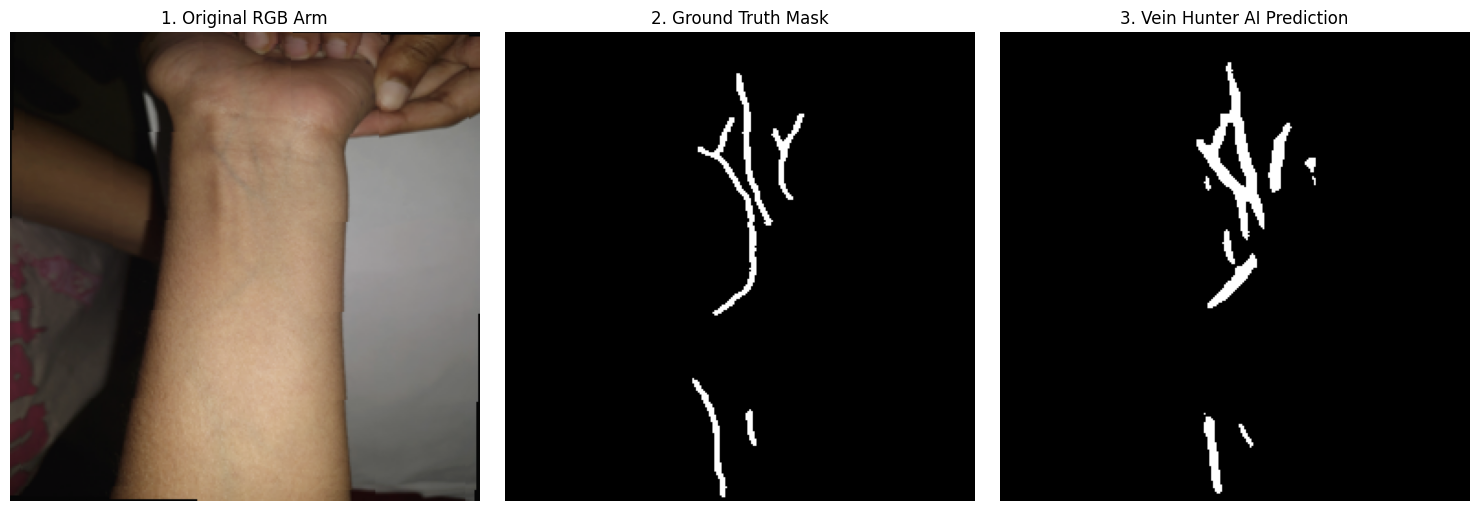

In [16]:
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# 1. Load the finalized Skin Weights
inference_model = VeinHunterUNet().to(device)
inference_model.load_state_dict(torch.load('/kaggle/working/vein_hunter_FINAL_SKIN_weights.pth'))
inference_model.eval() 

# 2. Grab a batch of unseen arm photos
images, true_masks = next(iter(val_loader))
single_image = images[0].unsqueeze(0).to(device) 
true_mask = true_masks[0].squeeze().numpy()

# 3. Make the Prediction
with torch.no_grad():
    prediction = inference_model(single_image)
    
pred_mask = prediction.squeeze().cpu().numpy()
binary_pred_mask = (pred_mask > 0.5).astype(float)

# 4. Plot the Results side-by-side
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Original RGB Image
img_display = images[0].permute(1, 2, 0).numpy()
ax[0].imshow(img_display)
ax[0].set_title("1. Original RGB Arm")
ax[0].axis('off')

# Ground Truth
ax[1].imshow(true_mask, cmap='gray')
ax[1].set_title("2. Ground Truth Mask")
ax[1].axis('off')

# AI Prediction
ax[2].imshow(binary_pred_mask, cmap='gray')
ax[2].set_title("3. Vein Hunter AI Prediction")
ax[2].axis('off')

plt.tight_layout()
plt.show()

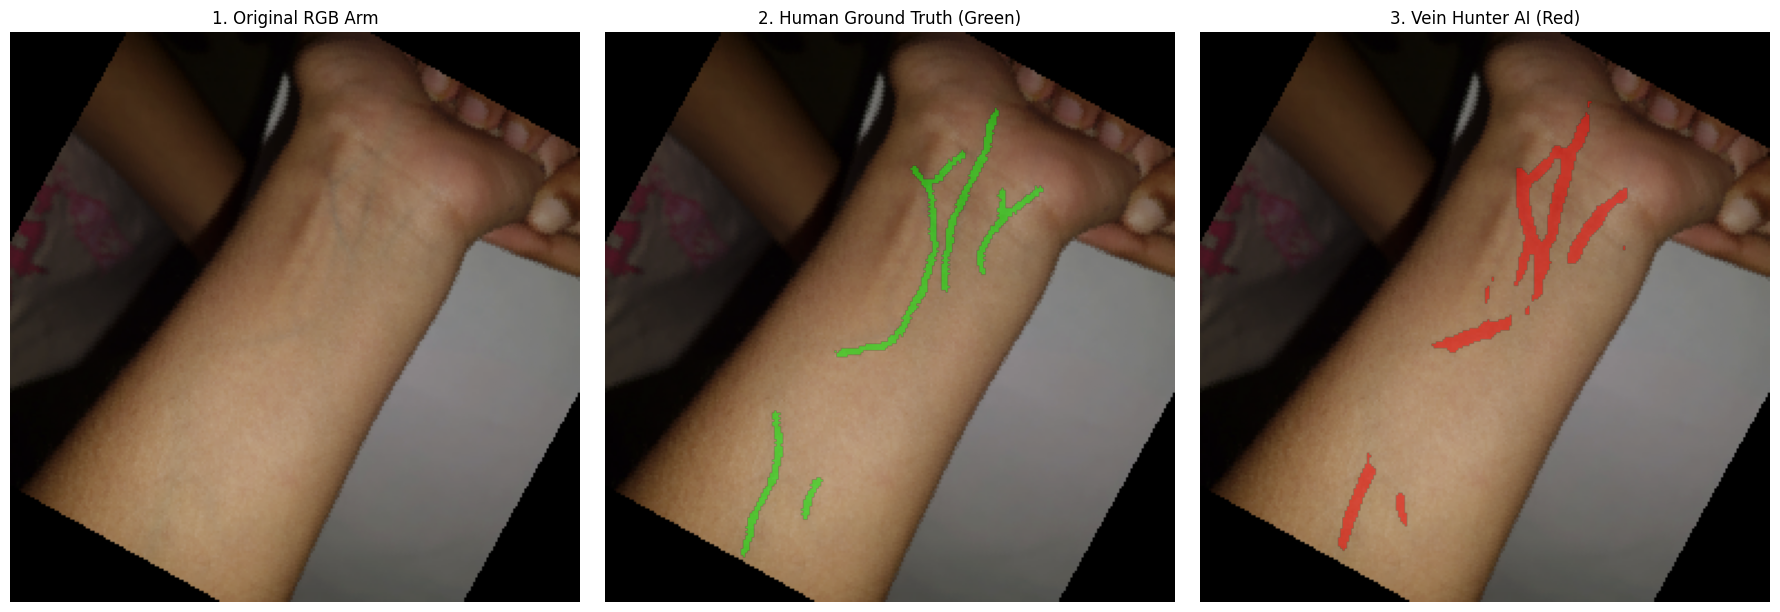

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# 1. Load the finalized Skin Weights
inference_model = VeinHunterUNet().to(device)
inference_model.load_state_dict(torch.load('/kaggle/working/vein_hunter_FINAL_SKIN_weights.pth'))
inference_model.eval() 

# 2. Grab a batch of unseen arm photos
images, true_masks = next(iter(val_loader))
single_image = images[0].unsqueeze(0).to(device) 
true_mask = true_masks[0].squeeze().numpy()

# 3. Make the Prediction
with torch.no_grad():
    prediction = inference_model(single_image)
    
pred_mask = prediction.squeeze().cpu().numpy()
binary_pred_mask = (pred_mask > 0.5).astype(float)

# Convert RGB image for Matplotlib (C, H, W -> H, W, C)
img_display = images[0].permute(1, 2, 0).numpy()

# ==========================================
# NEW: Create Transparent Color Overlays
# ==========================================
# Create a blank RGBA (Red, Green, Blue, Alpha) canvas for the Ground Truth
gt_overlay = np.zeros((*true_mask.shape, 4)) 
# Paint the true vein pixels Green [R=0, G=1, B=0] with 50% opacity [Alpha=0.5]
gt_overlay[true_mask == 1] = [0, 1, 0, 0.5]  

# Create a blank RGBA canvas for the AI Prediction
pred_overlay = np.zeros((*binary_pred_mask.shape, 4)) 
# Paint the predicted vein pixels Red [R=1, G=0, B=0] with 50% opacity [Alpha=0.5]
pred_overlay[binary_pred_mask == 1] = [1, 0, 0, 0.5]  

# ==========================================
# 4. Plot the Results side-by-side
# ==========================================
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Original RGB Image
ax[0].imshow(img_display)
ax[0].set_title("1. Original RGB Arm")
ax[0].axis('off')

# Panel 2: Ground Truth Overlay
ax[1].imshow(img_display)       # Draw the arm first
ax[1].imshow(gt_overlay)        # Draw the green transparency on top
ax[1].set_title("2. Human Ground Truth (Green)")
ax[1].axis('off')

# Panel 3: AI Prediction Overlay
ax[2].imshow(img_display)       # Draw the arm first
ax[2].imshow(pred_overlay)      # Draw the red transparency on top
ax[2].set_title("3. Vein Hunter AI (Red)")
ax[2].axis('off')

plt.tight_layout()
plt.show()

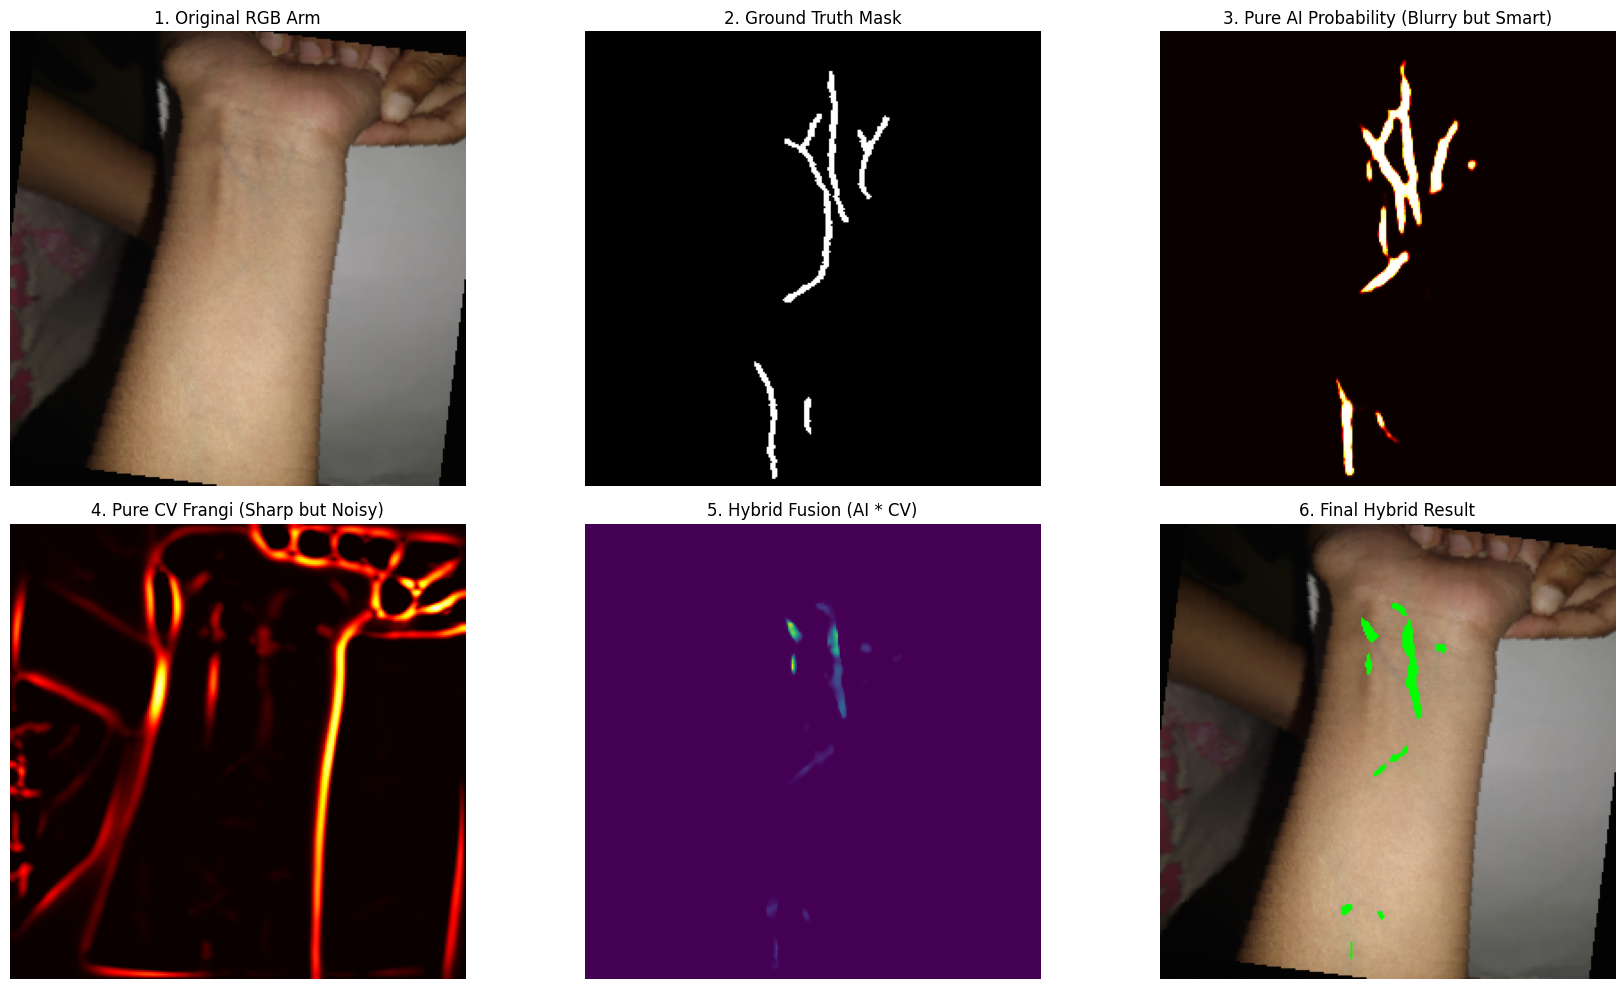

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from skimage.filters import frangi

# 1. Load the finalized Skin Weights
inference_model = VeinHunterUNet().to(device)
inference_model.load_state_dict(torch.load('/kaggle/working/vein_hunter_FINAL_SKIN_weights.pth'))
inference_model.eval()

# 2. Grab a batch of unseen arm photos
images, true_masks = next(iter(val_loader))
single_image_tensor = images[0].unsqueeze(0).to(device) 
true_mask = true_masks[0].squeeze().numpy()

# --- PHASE 1: THE AI PREDICTION (Semantic Understanding) ---
with torch.no_grad():
    prediction = inference_model(single_image_tensor)
    # The AI gives us a soft probability map (0.0 to 1.0)
    ai_prob_map = prediction.squeeze().cpu().numpy()

# --- PHASE 2: THE CV PIPELINE (Structural Precision from vein.py) ---
# Convert the PyTorch tensor (0.0 to 1.0) back to a standard OpenCV image (0 to 255)
img_display = images[0].permute(1, 2, 0).numpy()
img_uint8 = (img_display * 255).astype(np.uint8)

# Extract Green Channel (Index 1 in RGB)
green_channel = img_uint8[:, :, 1]

# Apply your aggressive preprocessing from vein.py
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
enhanced_green = clahe.apply(green_channel)
blurred_green = cv2.GaussianBlur(enhanced_green, (15, 15), 0)

# Calculate Frangi and normalize it to a probability map (0.0 to 1.0)
vein_probs_cv = frangi(blurred_green, sigmas=np.arange(3, 10, 2), black_ridges=True)
cv_prob_map = cv2.normalize(vein_probs_cv, None, 0, 1, cv2.NORM_MINMAX, dtype=cv2.CV_32F)


# --- PHASE 3: THE HYBRID FUSION ---
# We literally multiply the AI's intelligence by the CV's math.
# If AI says 0.9 (vein) and CV says 0.8 (tube), it becomes 0.72 (strong signal).
# If CV sees a hair (0.8) but AI knows it's not a vein (0.0), it becomes 0.0 (deleted!).
hybrid_map = ai_prob_map * cv_prob_map

# Normalize the fused map back to 0-255 for standard thresholding
hybrid_norm = cv2.normalize(hybrid_map, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# Apply threshold and morphological closing from your vein.py
_, binary_veins = cv2.threshold(hybrid_norm, 15, 255, cv2.THRESH_BINARY)
kernel = np.ones((5,5), np.uint8)
final_hybrid_veins = cv2.morphologyEx(binary_veins, cv2.MORPH_CLOSE, kernel)


# --- PHASE 4: VISUALIZATION ---
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

# Top Row: The Raw Data & AI
ax[0, 0].imshow(img_display)
ax[0, 0].set_title("1. Original RGB Arm")
ax[0, 0].axis('off')

ax[0, 1].imshow(true_mask, cmap='gray')
ax[0, 1].set_title("2. Ground Truth Mask")
ax[0, 1].axis('off')

ax[0, 2].imshow(ai_prob_map, cmap='hot')
ax[0, 2].set_title("3. Pure AI Probability (Blurry but Smart)")
ax[0, 2].axis('off')

# Bottom Row: The CV & The Fusion
ax[1, 0].imshow(cv_prob_map, cmap='hot')
ax[1, 0].set_title("4. Pure CV Frangi (Sharp but Noisy)")
ax[1, 0].axis('off')

ax[1, 1].imshow(hybrid_map, cmap='viridis')
ax[1, 1].set_title("5. Hybrid Fusion (AI * CV)")
ax[1, 1].axis('off')

# Final green overlay on original image
overlay = img_display.copy()
# Create a green mask: where final_hybrid_veins is 255, set RGB to [0, 1, 0] (Green for floats)
overlay[final_hybrid_veins == 255] = [0, 1.0, 0] 

ax[1, 2].imshow(overlay)
ax[1, 2].set_title("6. Final Hybrid Result")
ax[1, 2].axis('off')

plt.tight_layout()
plt.show()

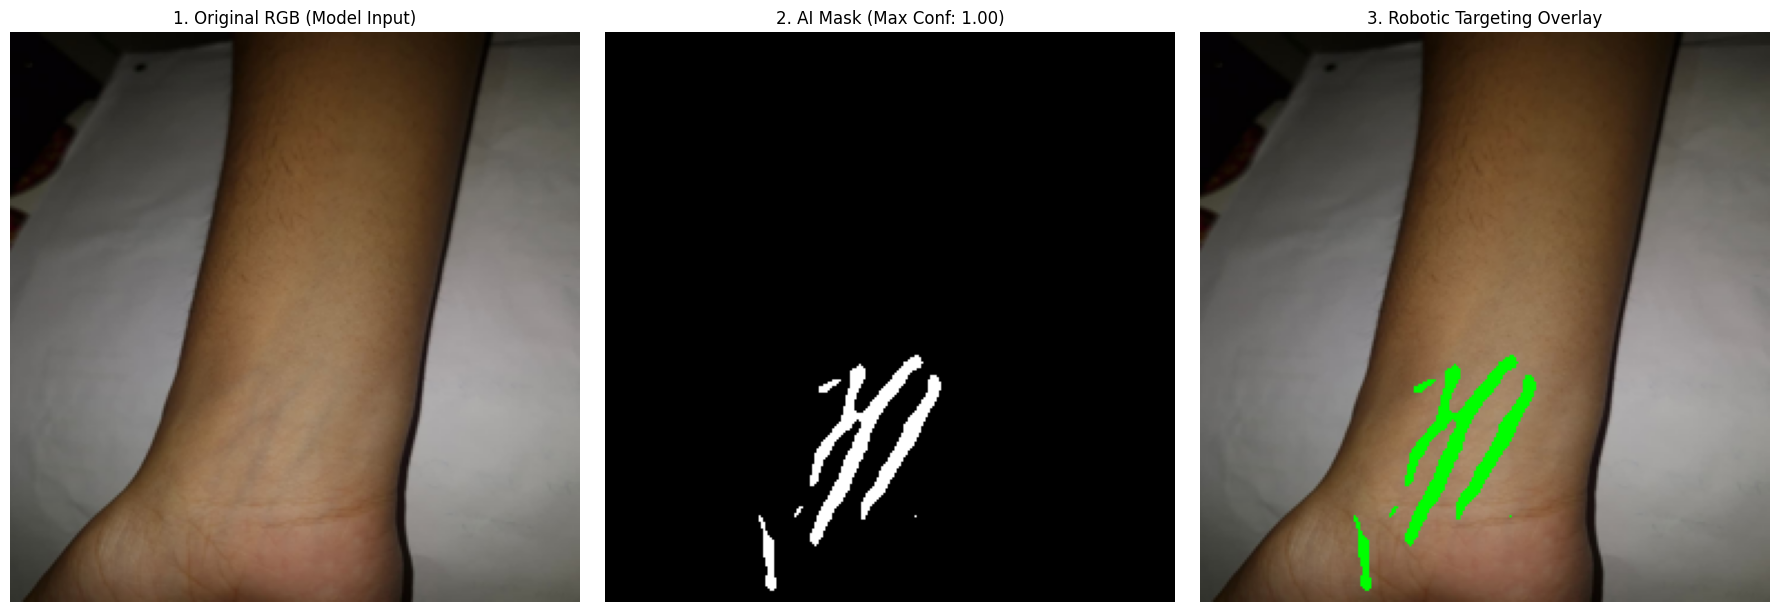

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from PIL import Image

def test_random_image_rgb(image_path, weights_path='/kaggle/working/vein_hunter_FINAL_SKIN_weights.pth'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 1. Load the Model
    model = VeinHunterUNet().to(device)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval() # Freezes Dropout and BatchNorm

    # 2. Load the Raw Image
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Error: Could not load image at {image_path}")
        return
        
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # 3. Resize EXACTLY as done in standard training
    pil_raw_rgb = Image.fromarray(img_rgb).resize((256, 256)) 
    
    # Convert to PyTorch Tensor
    # NOTE: If you used transforms.Normalize() in your train_loader, 
    # you MUST add it to this Compose pipeline here too!
    transform = transforms.Compose([
        transforms.ToTensor()
    ])
    input_tensor = transform(pil_raw_rgb).unsqueeze(0).to(device)

    # 4. Predict
    with torch.no_grad():
        prediction = model(input_tensor)
        # Squeeze out the batch dimension
        pred_prob = prediction.squeeze().cpu().numpy()
        
    # Strict thresholding
    binary_mask = (pred_prob > 0.5).astype(np.uint8)

    # 5. Overlay
    overlay = np.array(pil_raw_rgb).copy()
    overlay[binary_mask == 1] = [0, 255, 0]

    # Plot everything side-by-side
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    
    ax[0].imshow(pil_raw_rgb)
    ax[0].set_title("1. Original RGB (Model Input)")
    ax[0].axis('off')

    ax[1].imshow(binary_mask, cmap='gray')
    ax[1].set_title(f"2. AI Mask (Max Conf: {pred_prob.max():.2f})")
    ax[1].axis('off')

    ax[2].imshow(overlay)
    ax[2].set_title("3. Robotic Targeting Overlay")
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()

# --- RUN IT ---
test_random_image_rgb('/kaggle/input/datasets/pragatirokade/newtest/newtest.jpeg')